# Battlesnake com A*

A* é um algoritmo de busca de caminho que encontra o caminho mais curto entre dois pontos em um grafo. Ele é amplamente utilizado em jogos e aplicações de inteligência artificial para encontrar rotas eficientes. O algoritmo combina a busca em largura com uma heurística que estima o custo restante para chegar ao destino, permitindo que ele explore os caminhos mais promissores primeiro.

## O que é o Battlesnake? 

Segundo o [site oficial](https://docs.battlesnake.com): "_Battlesnake_ é um jogo de programação competitivo onde seu código é o controle".

Cada jogador controla uma cobra que deve se mover pelo tabuleiro, coletando comida e evitando colisões com outras cobras e com as bordas do tabuleiro. O objetivo é sobreviver o maior tempo possível.
Cade cobra é controlada através de uma API.
Nós conhecemos esse evento através do *Campeonato Battlesnake* organizado anualmente pela [Dev. Community Mauá](https://www.instagram.com/devcommunitymaua/).
Eles desenvolveram um _template_ que utilizamos de base para nosso projeto. Todos estão convidados a utilizar o [template](https://github.com/Maua-Dev/battlesnake_fastapi_template) para desenvolver suas cobras e participar do campeonato.

## O que exatamente fizemos?

Neste projeto, fizemos a nossa própria interpretação da API do jogo, utilizando o algoritmo A* para encontrar o caminho mais curto até a comida. O código é dividido em duas partes principais: a <b>_implementação do algoritmo A*_</b> e a <b>_lógica do Battlesnake_</b>.

# 1. _Imports_ necessários

In [26]:
from typing import List, Optional, Tuple
from random import randint
from math import pow
import numpy as np
import matplotlib.pyplot as plt

# 2. Criando as classes e funções de estrutura do jogo

## Criação de classes para representar as entidades do problema

Nossa modelagem do problema utilizou-se 3 classes principais: 

### a) `Coordinate`
- Representa as coordenadas no tabuleiro

In [27]:
class Coordinate:
    x: float
    y: float

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __hash__(self):
        return hash((self.x, self.y))

    @staticmethod
    def from_json(json):
        return Coordinate(json['x'], json['y'])

    def __repr__(self):
        return f"Coordinate: {self.x},{self.y}"

    @staticmethod
    def distance(a, b): 
        return abs(a.x - b.x) + abs(a.y - b.y)

    @staticmethod
    def heuristic_function(a, b):
        return pow(a.x - b.x, 2) + pow(a.y - b.y, 2)

    def move_command(self, move: str):
        if move == "up":
            return Coordinate(self.x, self.y + 1)
        elif move == "down":
            return Coordinate(self.x, self.y - 1)
        elif move == "left":
            return Coordinate(self.x - 1, self.y)
        elif move == "right":
            return Coordinate(self.x + 1, self.y)
        else:
            return Coordinate(self.x, self.y)

### b) `Battlesnake` 
- Representa cada cobra, posição da cabeça, corpo, vida e outras características interessantes para a montagem da estratégia

In [28]:
class Battlesnake:
    snake_id: str
    name: str
    health: int
    body: List[Coordinate]
    latency: str
    head: Coordinate
    length: int
    shout: str
    squad: str
    color: str


    def __init__(self, snake_id: str, name: str, health: int, body: List[Coordinate], latency: str, head: Coordinate, length: int, shout: str, squad: str, color: str = "#888888"):
        self.snake_id = snake_id
        self.name = name
        self.health = health
        self.body = body
        self.latency = latency
        self.head = head
        self.length = length
        self.shout = shout
        self.squad = squad
        self.color = color

    def __eq__(self, other):
        return self.snake_id == other.snake_id and self.name == other.name and self.health == other.health and self.body == other.body and self.latency == other.latency and self.head == other.head and self.length == other.length and self.shout == other.shout and self.squad == other.squad

    def __repr__(self):
        return f"Snake: {self.name} ({self.snake_id})"

    @staticmethod
    def from_json(json):
        snake_id = json["id"]
        name = json["name"]
        health = json["health"]
        body = [Coordinate.from_json(body) for body in json["body"]]
        latency = json["latency"]
        head = Coordinate.from_json(json["head"])
        length = json["length"]
        shout = json["shout"]
        squad = json.get("squad", "")
        color = json["customizations"].get("color", "#888888")
        return Battlesnake(snake_id, name, health, body, latency, head, length, shout, squad, color)

    def is_inside_snake(self, coordinate: Coordinate):
        for body in self.body:
            if body == coordinate:
                return True
        return False

    # def is_near_head(self, coordinate: Coordinate):
    #     if Coordinate.distance(self.head, coordinate) <= 1:
    #         return True
    #     return False

### c) `Board` 
- Une todas as informações do tabuleiro, como a posição da comida e das cobras.

In [29]:
class Board:
  height: int
  width: int
  food: List[Coordinate]
  snakes: List[Coordinate]
  hazards: List[Battlesnake]

  def __init__(self, height: int, width: int, food: List[Coordinate], snakes: List[Coordinate], hazards: List[Battlesnake]):
      self.food = food
      self.height = height
      self.width = width
      self.snakes = snakes
      self.hazards = hazards


  def __eq__(self, other):
      return self.height == other.height and self.width == other.width and self.food == other.food and self.snakes == other.snakes and self.hazards == other.hazards

  def __repr__(self):
      return f"Board: {self.width}x{self.height}"

  @staticmethod
  def from_json(json):
      height = json["height"]
      width = json["width"]
      food = [Coordinate.from_json(food) for food in json["food"]]
      snakes = [Battlesnake.from_json(snake) for snake in json["snakes"]]
      hazards = [Coordinate.from_json(hazard) for hazard in json["hazards"]]
      return Board(height, width, food, snakes, hazards)

  @staticmethod
  def navigate_to(start: Coordinate, end: Coordinate) -> str:
      if start.x < end.x:
          return "right"
      elif start.x > end.x:
          return "left"
      elif start.y < end.y:
          return "up"
      elif start.y > end.y:
          return "down"
      else:
          return "up"
    
  def reconstruct_path(self, came_from: dict, current: Coordinate) -> List[Coordinate]:
        total_path = [current]
        while current in came_from:
            current = came_from[current]
            total_path.append(current)
        return total_path[::-1]
      
  def find_path(self, start: Coordinate, end: Coordinate) -> List[Coordinate]:
        
        if end is None:
            return []
        if start == end:
            return [start]
        
        open_set = [start]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: Coordinate.heuristic_function(start, end)}
    
        while open_set:
            current = min(open_set, key=lambda x: f_score.get(x, float('inf')))
    
            if current == end:
                return self.reconstruct_path(came_from, current)
    
            open_set.remove(current)
    
            for neighbor in self.get_valid_neighbors(current):
                tentative_g_score = g_score.get(current, float('inf')) + 1
    
                if tentative_g_score < g_score.get(neighbor, float('inf')):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + Coordinate.heuristic_function(neighbor, end)
                    if neighbor not in open_set:
                        open_set.append(neighbor)
    
        return []

  def get_path_to_all_foods(self, me: Battlesnake) -> List[List[Coordinate]]:
      paths = []
      for food in self.food:
          path = self.find_path(me.head, food)
          if path:
              paths.append(path)
      return paths
  
  def get_path_to_closest_food(self, me: Battlesnake) -> List[Coordinate]:
        if len(self.food) == 0:
            return []
        paths = self.get_path_to_all_foods(me)
        paths.sort(key=lambda x: len(x))
        if len(paths) > 0:
            return paths[0]
        return []
  
  def get_all_foods(self):
        return self.food

  def get_valid_neighbors(self, head: Coordinate) -> List[Coordinate]:
      neighbors = []
      for move in ["right", "down", "left", "up"]:
          if self.can_move(move, head):
              new_coordinate = head.move_command(move)
              neighbors.append(new_coordinate)
      return neighbors

  def is_snake(self, move: str, head: Coordinate):
      coordinate = head.move_command(move)
      for snake in self.snakes:
          if snake.is_inside_snake(coordinate):
              return snake
      return False
  
  def get_closest_food(self, me: Battlesnake) -> Optional[Coordinate]:
        closest_food = None
        min_distance = float('inf')
        for food in self.food:
            distance = Coordinate.distance(me.head, food)
            if distance < min_distance:
                min_distance = distance
                closest_food = food
        return closest_food
  
  def is_hazard(self, move: str, head: Coordinate):
      coordinate = head.move_command(move)
      for hazard in self.hazards:
          if hazard == coordinate:
              return True
      return False

  def dodge_snake_body(self, me: Battlesnake, old_move: str):
      if  self.can_move(old_move, me.head):
          return old_move

      for move in ["up", "down", "left", "right"]:
          if self.can_move(move, me.head):
              return move
      return old_move
  
  def can_move(self, move: str, coordinate: Coordinate) -> bool:
        if self.is_out_of_bounds(move, coordinate) or self.is_snake(move, coordinate) or self.is_hazard(move, coordinate):
            return False
        return True

  def is_out_of_bounds(self, move: str, head: Coordinate):
      coordinate = head.move_command(move)
      if coordinate.x < 0 or coordinate.x >= self.width or coordinate.y < 0 or coordinate.y >= self.height:
          return True
      return False
  
  def safe_random_move(self, me: Battlesnake) -> str:
        for move in ["up", "down", "left", "right"]:
            if self.can_move(move, me.head) and not self.is_near_snake(me.head.move_command(move), me):
                return move
        return "up"  # Default move if no safe moves are available
  
  def is_near_snake(self, coordinate: Coordinate, me: Battlesnake) -> bool:
        for snake in self.snakes:
            if Coordinate.distance(snake.head, coordinate) <= 1 and snake.snake_id != me.snake_id:
                if snake.length >= me.length:
                    return True
        return False  


## Exemplo de _request_ transformado nas classes moldadas

### _Request_

In [30]:
request = {
   'game':{
      'id':'ee76919a-ed0b-44aa-bb6b-658e6cadad92',
      'ruleset':{
         'name':'standard',
         'version':'v1.2.3',
         'settings':{
            'foodSpawnChance':15,
            'minimumFood':1,
            'hazardDamagePerTurn':0,
            'hazardMap':'',
            'hazardMapAuthor':'',
            'royale':{
               'shrinkEveryNTurns':0
            },
            'squad':{
               'allowBodyCollisions':False,
               'sharedElimination':False,
               'sharedHealth':False,
               'sharedLength':False
            }
         }
      },
      'map':'standard',
      'timeout':500,
      'source':'custom'
   },
   'turn':33,
   'board':{
      'height':7,
      'width':7,
      'snakes':[
         {
            'id':'gs_GdCjGhdYjWkD4vDYQHT7gf3B',
            'name':'ssssoller',
            'latency':'29',
            'health':97,
            'body':[
               {
                  'x':6,
                  'y':3
               },
               {
                  'x':5,
                  'y':3
               },
               {
                  'x':4,
                  'y':3
               },
               {
                  'x':4,
                  'y':4
               },
               {
                  'x':3,
                  'y':4
               },
               {
                  'x':3,
                  'y':3
               },
               {
                  'x':3,
                  'y':2
               },
               {
                  'x':3,
                  'y':1
               }
            ],
            'head':{
               'x':6,
               'y':3
            },
            'length':8,
            'shout':'Tá ligado, cachorro do mangue?',
            'squad':'',
            'customizations':{
               'color':'#ff5f1f',
               'head':'chicken',
               'tail':'flytrap'
            }
         },
         {
            'id':'gs_BXyRxMR7rBFpVSSWWcXwpS8W',
            'name':'ssssoller',
            'latency':'28',
            'health':82,
            'body':[
               {
                  'x':2,
                  'y':5
               },
               {
                  'x':2,
                  'y':6
               },
               {
                  'x':3,
                  'y':6
               },
               {
                  'x':4,
                  'y':6
               },
               {
                  'x':4,
                  'y':5
               }
            ],
            'head':{
               'x':2,
               'y':5
            },
            'length':5,
            'shout':'Naquele naipão',
            'squad':'',
            'customizations':{
               'color':'#ff5f1f',
               'head':'chicken',
               'tail':'flytrap'
            }
         }
      ],
      'food':[
         {
            'x':6,
            'y':5
         },
         {
            'x':6,
            'y':2
         },
         {
            'x':1,
            'y':0
         }
      ],
      'hazards':[

      ]
   },
   'you':{
      'id':'gs_BXyRxMR7rBFpVSSWWcXwpS8W',
      'name':'ssssoller',
      'latency':'28',
      'health':82,
      'body':[
         {
            'x':2,
            'y':5
         },
         {
            'x':2,
            'y':6
         },
         {
            'x':3,
            'y':6
         },
         {
            'x':4,
            'y':6
         },
         {
            'x':4,
            'y':5
         }
      ],
      'head':{
         'x':2,
         'y':5
      },
      'length':5,
      'shout':'Naquele naipão',
      'squad':'',
      'customizations':{
         'color':'#ff5f1f',
         'head':'chicken',
         'tail':'flytrap'
      }
   }
}

### Transformação do JSON

In [31]:
board = Board.from_json(request["board"])
me = Battlesnake.from_json(request["you"])

## Visualizando o tabuleiro de forma gráfica

Função que desenha o tabuleiro, cobras e futuramente o caminho encontrado pelo A*:

In [32]:
def draw_path(board: Board, path: List[Coordinate], me: Battlesnake):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, board.width)
    ax.set_ylim(0, board.height)
    ax.set_xticks(np.arange(0, board.width + 1, 1))
    ax.set_yticks(np.arange(0, board.height + 1, 1))
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)
    
    food_patch = None
    me_patch = None
    enemey_patch = None
    head_patch = None
    hazard_patch = None



    for food in board.food:
        food_patch = ax.add_patch(plt.Circle((food.x + 0.5, food.y + 0.5), 0.2, color='purple', label='Food'))

    

    for snake in board.snakes:
        for body in snake.body:

            

            if snake.snake_id == me.snake_id:
                me_patch = ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color='blue', label='Me'))
            else:
                enemey_patch = ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color='red', label='Enemy'))

            if body == snake.head:
                head_patch = ax.add_patch(plt.Circle((body.x + 0.5, body.y + 0.5), 0.3, color='yellow', label='Head'))

    for hazard in board.hazards:
        hazard_patch = ax.add_patch(plt.Rectangle((hazard.x, hazard.y), 1, 1, color='black', label='Hazard', alpha=0.5))
    
    path_hanldle = None

    for coordinate in path:
        path_hanldle = ax.add_patch(plt.Circle((coordinate.x + 0.5, coordinate.y + 0.5), 0.1, color='black', label='Path'))
        if coordinate != path[-1]:
            next_coordinate = path[path.index(coordinate) + 1]
            ax.plot([coordinate.x + 0.5, next_coordinate.x + 0.5], [coordinate.y + 0.5, next_coordinate.y + 0.5], color='black', linewidth=2)

    handles = [food_patch, me_patch, enemey_patch, head_patch, hazard_patch, path_hanldle]
    handles = [handle for handle in handles if handle is not None]
    
    ax.legend(loc='best', handles=handles, fontsize='small')

    plt.show()

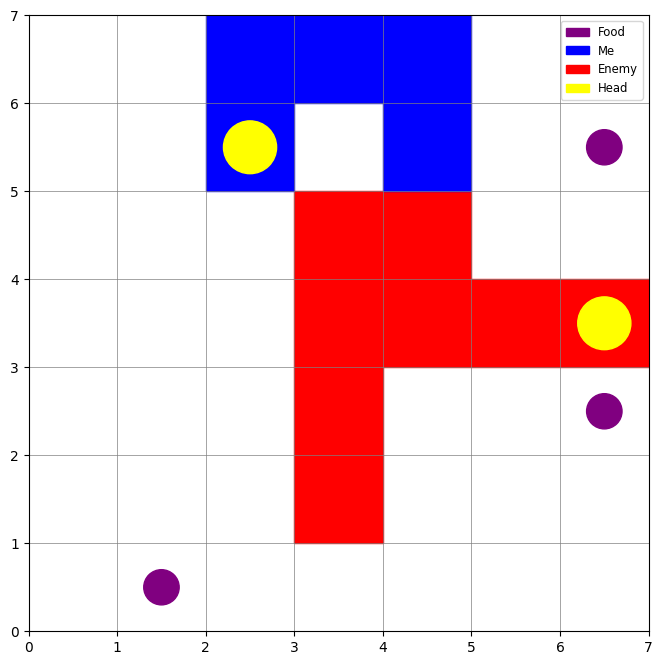

In [33]:
draw_path(board,[], me)

# Get path to all foods

[Coordinate: 2,5, Coordinate: 2,4, Coordinate: 2,3, Coordinate: 2,2, Coordinate: 2,1, Coordinate: 2,0, Coordinate: 3,0, Coordinate: 4,0, Coordinate: 5,0, Coordinate: 5,1, Coordinate: 6,1, Coordinate: 6,2]


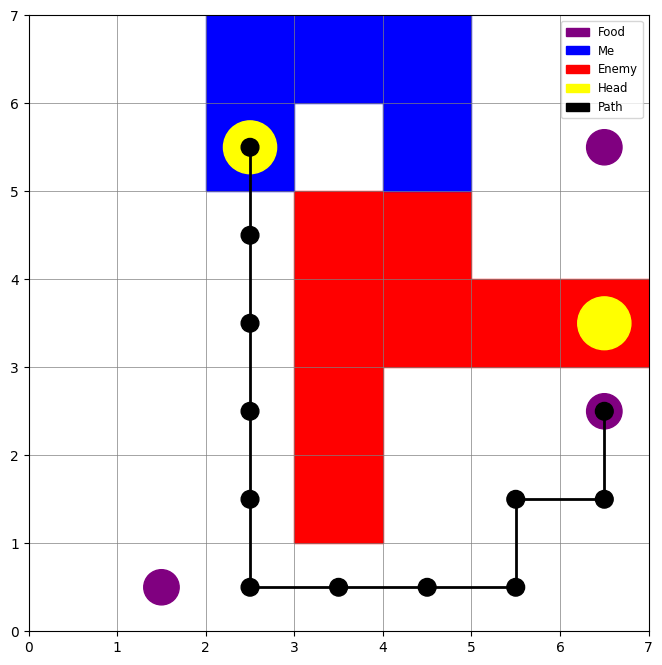

[Coordinate: 2,5, Coordinate: 2,4, Coordinate: 2,3, Coordinate: 2,2, Coordinate: 2,1, Coordinate: 2,0, Coordinate: 1,0]


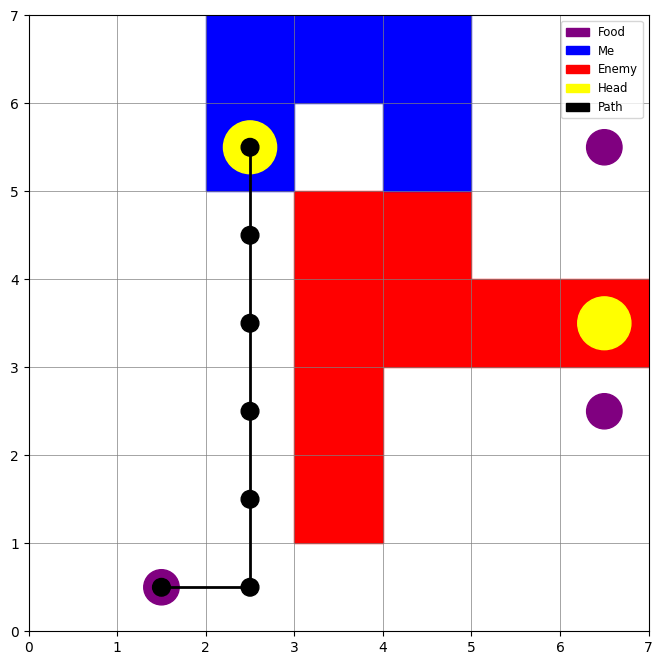

In [34]:
paths = board.get_path_to_all_foods(me)

for path in paths:
    print(path)
    draw_path(board, path, me)

Path para comida mais próxima

[Coordinate: 2,5, Coordinate: 2,4, Coordinate: 2,3, Coordinate: 2,2, Coordinate: 2,1, Coordinate: 2,0, Coordinate: 1,0]


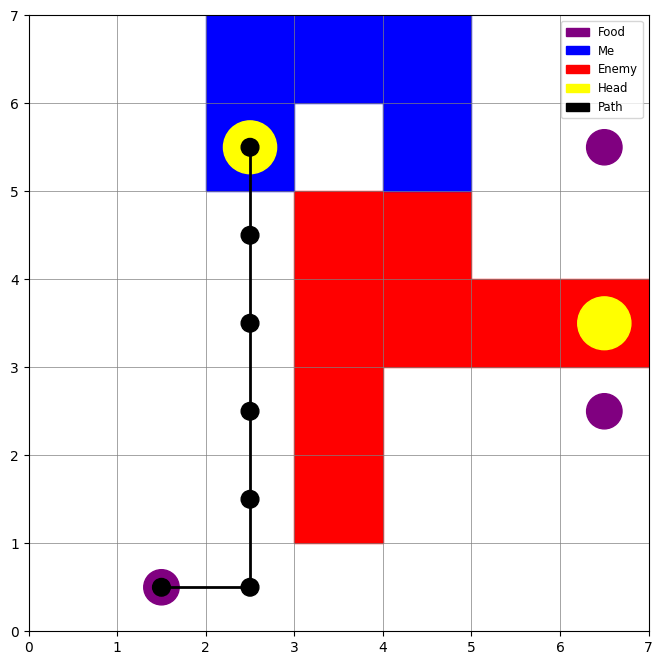

In [35]:
path = board.get_path_to_closest_food(me)
print(path)
draw_path(board, path, me)

proximo movimento

In [36]:
print(path)

print("Proximo movimento: ", board.navigate_to(me.head, path[1]))

[Coordinate: 2,5, Coordinate: 2,4, Coordinate: 2,3, Coordinate: 2,2, Coordinate: 2,1, Coordinate: 2,0, Coordinate: 1,0]
Proximo movimento:  down


Testando a cabeça com cabeça

In [37]:
request = {'game': {'id': '83d269d2-958e-4d1b-af9c-bc400020442c', 'ruleset': {'name': 'standard', 'version': 'v1.2.3', 'settings': {'foodSpawnChance': 15, 'minimumFood': 1, 'hazardDamagePerTurn': 0, 'hazardMap': '', 'hazardMapAuthor': '', 'royale': {'shrinkEveryNTurns': 0}, 'squad': {'allowBodyCollisions': False, 'sharedElimination': False, 'sharedHealth': False, 'sharedLength': False}}}, 'map': 'standard', 'timeout': 500, 'source': 'custom'}, 'turn': 18, 'board': {'height': 11, 'width': 11, 'snakes': [{'id': 'gs_PBWGQ3rHTGKG3PmHv93Wx3w9', 'name': 'SoBrRuMaSa_ASTAR', 'latency': '31', 'health': 88, 'body': [{'x': 3, 'y': 5}, {'x': 3, 'y': 4}, {'x': 3, 'y': 3}, {'x': 3, 'y': 2}, {'x': 4, 'y': 2}], 'head': {'x': 3, 'y': 5}, 'length': 5, 'shout': "I'm moving up!", 'squad': '', 'customizations': {'color': '#ffde21', 'head': 'ski', 'tail': 'weight'}}, {'id': 'gs_qwHgTSJqd7T8dgpB94f9Cfpc', 'name': 'Hungry Bot', 'latency': '1', 'health': 97, 'body': [{'x': 2, 'y': 4}, {'x': 2, 'y': 3}, {'x': 2, 'y': 2}, {'x': 2, 'y': 1}, {'x': 1, 'y': 1}], 'head': {'x': 2, 'y': 4}, 'length': 5, 'shout': '', 'squad': '', 'customizations': {'color': '#00cc00', 'head': 'alligator', 'tail': 'alligator'}}], 'food': [{'x': 1, 'y': 6}, {'x': 2, 'y': 6}, {'x': 7, 'y': 10}], 'hazards': []}, 'you': {'id': 'gs_PBWGQ3rHTGKG3PmHv93Wx3w9', 'name': 'SoBrRuMaSa_ASTAR', 'latency': '31', 'health': 88, 'body': [{'x': 3, 'y': 5}, {'x': 3, 'y': 4}, {'x': 3, 'y': 3}, {'x': 3, 'y': 2}, {'x': 4, 'y': 2}], 'head': {'x': 3, 'y': 5}, 'length': 5, 'shout': "I'm moving up!", 'squad': '', 'customizations': {'color': '#ffde21', 'head': 'ski', 'tail': 'weight'}}}


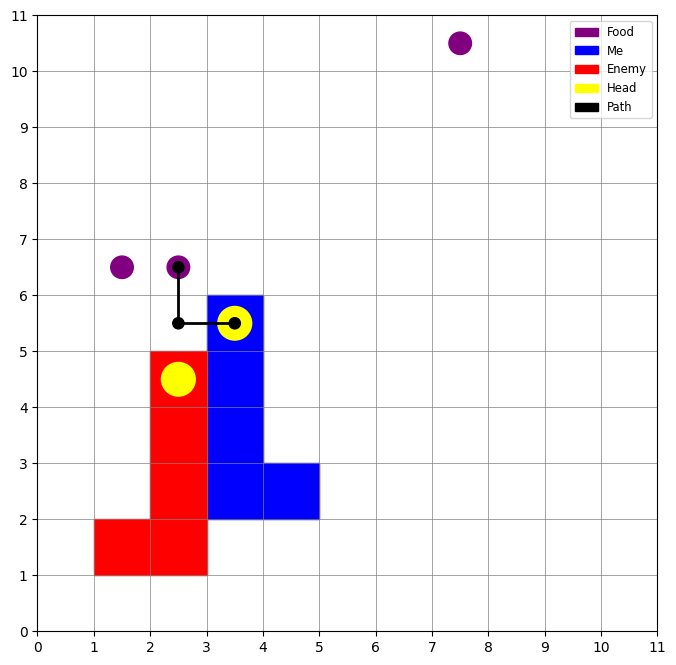

Proximo movimento:  up


In [48]:
board = Board.from_json(request["board"])
me = Battlesnake.from_json(request["you"])


path = board.get_path_to_closest_food(me)

draw_path(board, path, me)

if len(path) > 0:
    next_move = board.navigate_to(me.head, path[1])
    if board.is_near_snake(me.head.move_command(next_move), me):
        next_move = board.safe_random_move(me)
else:
    next_move = board.safe_random_move(me)

print("Proximo movimento: ", next_move) 